https://github.com/NASA-IMPACT/hls-foundation-os/blob/main/exploration.ipynb

In [4]:
!uv pip install contextily

Resolved 30 packages in 1.06s                                                
Downloaded 5 packages in 116ms.2                                    
Installed 5 packages in 2ms1.2.1                                    
 + contextily==1.6.2
 + geographiclib==2.0
 + geopy==2.4.1
 + mercantile==1.2.1
 + xyzservices==2025.1.0


In [8]:
# !apt-get update && apt-get install git-lfs -y
# !git lfs install
# !cd "data/" && git clone "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M" && cd -

In [5]:
!uv pip install -r "data/Prithvi-EO-2.0-300M/requirements.txt"

Resolved 46 packages in 1.01s                                                
Downloaded 4 packages in 368ms5.3                                   
Installed 4 packages in 6ms                                         
 + einops==0.8.1
 + huggingface-hub==0.29.1
 + safetensors==0.5.3
 + timm==1.0.15


In [6]:
import sys
sys.path.append("data/Prithvi-EO-2.0-300M/")

In [7]:
import os
from os.path import join
from pathlib import Path
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import json
from tqdm.auto import tqdm

from prithvi_mae import PrithviMAE

NO_DATA = -9999
NO_DATA_FLOAT = 0.0001
PERCENTILES = (0.1, 99.9)
DEVICE = "cuda"

In [9]:
root = Path("data/Prithvi-EO-2.0-300M/")

In [10]:
# load weights
weights_path = root / "Prithvi_EO_V2_300M.pt"
checkpoint = torch.load(weights_path, map_location="cpu")

# read model config
model_cfg_path = root / "config.json"
with open(model_cfg_path) as f:
    model_config = json.load(f)

# let us use only 1 frame for now (the model was trained on 3 frames)
model_config["num_frames"] = 1

# instantiate model
model = PrithviMAE(**model_config["pretrained_cfg"])
model.eval()

# load weights into model
# strict=false since we are loading with only 1 frame, but the warning is expected
del checkpoint['encoder.pos_embed']
del checkpoint['decoder.decoder_pos_embed']

model.load_state_dict(checkpoint, strict=False)
model = model.to(DEVICE)

/tmp/ipykernel_74/492960533.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weights_path, map_location="cpu")


In [11]:
# statistics used to normalize images before passing to the model
means = np.array(model_config["pretrained_cfg"]["mean"]).squeeze()
stds = np.array(model_config["pretrained_cfg"]["std"]).squeeze()

# def preprocess_image(image):
#     # normalize image
#     C, H, W = image.shape
#     normalized = image.copy()
#     normalized = ((image - means) / stds)
#     normalized = normalized.reshape(1, C, 1, H, W)
#     normalized = torch.from_numpy(normalized).to(torch.float32)
#     return normalized

In [12]:
def features_to_embedding(features: list["torch.Tensor"]) -> "torch.Tensor":
    # index 0 is CLS token
    return features[-1][:, 0, :].squeeze()

---

In [13]:
import os

In [14]:
os.environ["GDAL_HTTP_NETRC_FILE"] = "/root/.netrc"
os.environ["CPL_DEBUG"] = "OFF"
os.environ["GDAL_NETRC"] = "YES"  # Forces GDAL to use ~/.netrc
os.environ["GDAL_HTTP_COOKIEFILE"] = "/tmp/cookies.txt"
os.environ["GDAL_HTTP_COOKIEJAR"] = "/tmp/cookies.txt"

In [33]:
import pystac_client
from pystac import ItemCollection
from rastervision.core.box import Box
from rastervision.core.data import (RasterioCRSTransformer, StatsTransformer,
                                    XarraySource)
from rastervision.core.data.raster_source import XarraySource
from shapely.geometry import mapping

In [16]:
import rasterio as rio

In [17]:
import albumentations as A
import pandas as pd
import geopandas as gpd

In [18]:
import contextily as cx
from matplotlib import pyplot as plt
from matplotlib import patches
import geopandas as gpd

In [19]:
BANDS = [
    'B02', # blue
    'B03', # green
    'B04', # red
    'B05', # rededge1
    'B06', # rededge2
    'B07', # rededge3
]

In [63]:
bbox = Box(ymin=36.17, xmin=36.11, ymax=36.23, xmax=36.19)
bbox_geometry = mapping(bbox.to_shapely().oriented_envelope)
bbox

Box(ymin=36.17, xmin=36.11, ymax=36.23, xmax=36.19)

In [64]:
%%time
URL = 'https://cmr.earthdata.nasa.gov/stac/LPCLOUD/'
catalog = pystac_client.Client.open(URL)

items = catalog.search(
    intersects=bbox_geometry,
    collections=['HLSL30_2.0', 'HLSS30_2.0'],
    datetime='2000-01-01/2025-12-31',
    query={'eo:cloud_cover': {'lt': 5}},
).item_collection()
len(items)

CPU times: user 144 ms, sys: 21.1 ms, total: 165 ms
Wall time: 30.3 s


520

In [ ]:
# for k, asset in items[0].assets.items():
#     if k not in ("B02", "B03", "B04", "B05", "B06", "B07"):
#         continue
#     with rio.open(asset.href) as ds:
#         print(k, ds.crs)

In [65]:
item_df = gpd.GeoDataFrame.from_features(items, crs="EPSG:4326")
print("#items original", len(item_df))
mask = item_df.contains(bbox.to_shapely())
items_filtered = ItemCollection([item for item, flag in zip(items, mask) if flag])
item_df = gpd.GeoDataFrame.from_features(items_filtered, crs="EPSG:4326")
print("#items that fully contain bbox", len(items_filtered))

# item_df['datetime'] = pd.to_datetime(item_df.loc[:, 'datetime'])
# item_df['date'] = item_df['datetime'].dt.date
# item_df = item_df.drop_duplicates(subset='date', keep='first')
# print("#items after date deduplication", len(item_df))

#items original 520
#items that fully contain bbox 385


In [ ]:
# URL = 'https://earth-search.aws.element84.com/v1'
# catalog = pystac_client.Client.open(URL)

# items_s2 = catalog.search(
#     intersects=bbox_geometry,
#     collections=['sentinel-2-c1-l2a'],
#     datetime='2025-01-01/2025-01-31',
#     query={'eo:cloud_cover': {'lt': 5}},
# ).item_collection()
# len(items_s2)

In [56]:
# raster_source_s2 = XarraySource.from_stac(
#     items_s2,
#     temporal=True,
#     allow_streaming=True,
#     stackstac_args=dict(assets=["red"], rescale=False, fill_value=0),
# )
# window = Box(ymin=1000, xmin=6000, ymax=1500, xmax=6500)
# raster_source_s2.crs_transformer.pixel_to_map(window, bbox=raster_source_s2.bbox)

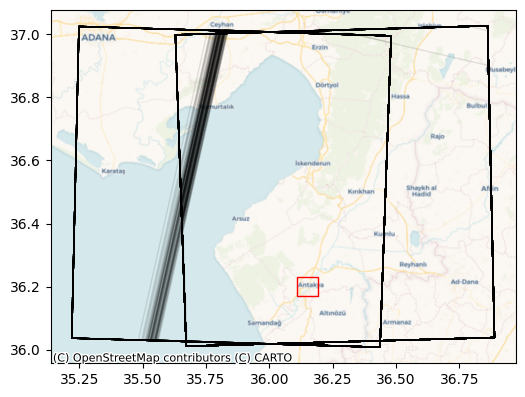

In [66]:
plt.close('all')
fig, ax = plt.subplots(figsize=(6, 6))

item_df.plot(ax=ax, ec='k', fc='none', alpha=0.1)
# gpd.GeoDataFrame.from_features(items_s2).plot(ax=ax, ec='g', fc='none')

# plot bbox
xy_coords = bbox.to_points()
bbox_patch = patches.Polygon(xy_coords, color='red', fill=False)
ax.add_patch(bbox_patch)

cx.add_basemap(ax, crs='epsg:4326', source=cx.providers.CartoDB.Voyager)

plt.show()

In [67]:
raster_source = XarraySource.from_stac(
    items_filtered,
    bbox_map_coords=tuple(bbox),
    temporal=True,
    stackstac_args=dict(
        rescale=False, 
        fill_value=0, 
        assets=BANDS, 
        epsg=32636,
        resolution=30,
    ),
    allow_streaming=True,
)
raster_source.shape, raster_source.dtype

((385, 230, 233, 6), dtype('float64'))

In [68]:
stats_tf_viz = StatsTransformer(means=means[[2, 1, 0]], stds=stds[[2, 1, 0]])
raster_source_viz = XarraySource(
    raster_source.data_array,
    channel_order=[2, 1, 0],  # RGB
    crs_transformer=raster_source.crs_transformer,
    raster_transformers=[stats_tf_viz],
    bbox=raster_source.bbox,
    temporal=True,
)
raster_source_viz.shape

(385, 230, 233, 3)

  0%|          | 0/8 [00:00<?, ?it/s]

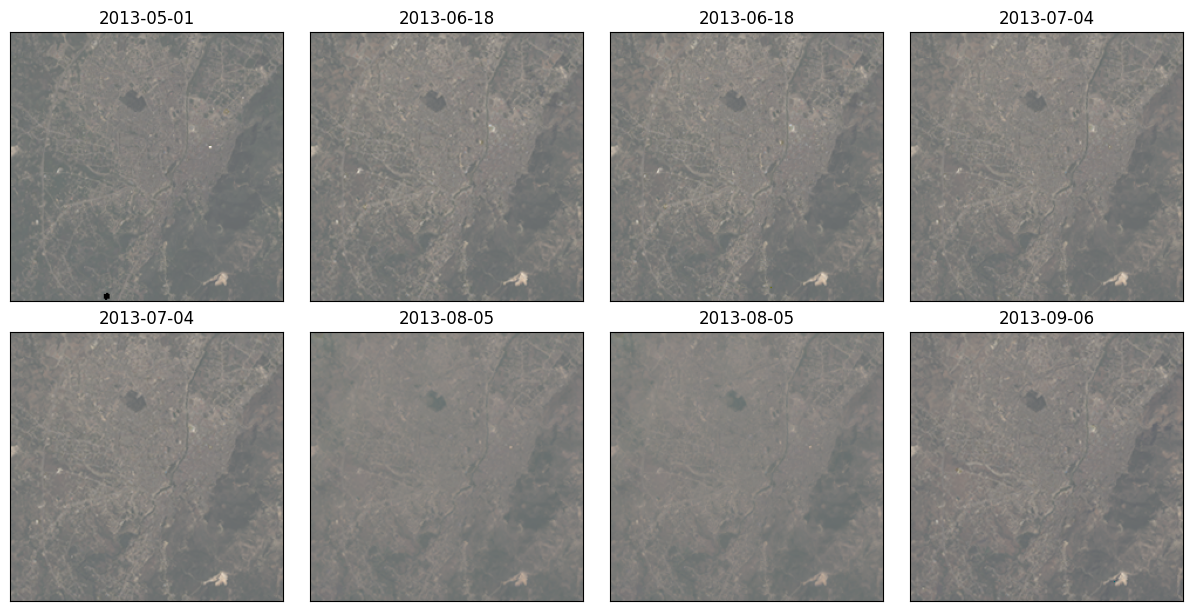

In [69]:
T = min(raster_source_viz.shape[0], 8)
dates = [str(s.date()) for s in raster_source_viz.data_array.time.to_series()]

ncols = 4
nrows = int(np.ceil(T / ncols))
fig, axs = plt.subplots(
    nrows, ncols, figsize=(ncols * 3, nrows * 3), constrained_layout=True)
with tqdm(zip(range(T), dates, axs.flat), total=T) as bar:
    for t, date, ax in bar:
        chip = raster_source_viz[t, :, :]
        ax.imshow(chip)
        ax.set_title(date, fontsize=12)
        ax.tick_params(top=False, bottom=False, left=False, right=False,
                    labelleft=False, labelbottom=False, labeltop=False)
for ax in axs.flat[T:]:
    ax.axis('off')
plt.show()

In [70]:
tf = A.Compose([
    A.Normalize(mean=means.tolist(), std=stds.tolist()),
    A.Resize(224, 224),
])

In [90]:
import time

class ChipDataset:
    def __init__(self, raster_source, transform):
        self.raster_source = raster_source
        self.transform = transform
        
    def __getitem__(self, i):
        flag = 1
        for attempts in range(3):
            try:
                x = self.raster_source[i, ...]
                break
            except:
                print("Retrying ...")
                time.sleep(3)
        else:
            x = np.zeros((224, 224, 6))
            flag = 0
        x = self.transform(image=x)["image"]
        x = x.transpose(2, 0, 1)
        return x, torch.nan, flag

    def __len__(self):
        return raster_source.shape[0]

In [91]:
ds = ChipDataset(raster_source, tf)
dl = DataLoader(ds, batch_size=4, num_workers=0, shuffle=False, pin_memory=True)
len(ds), len(dl)

(385, 97)

In [ ]:
emb_dims = 1024
embeddings = torch.zeros(len(ds), emb_dims)
quality_flags = np.zeros(len(ds), dtype=np.uint8)

i = 0
with torch.inference_mode(), tqdm(dl, desc='Creating embeddings') as bar:
    for x, _, flags  in bar:
        x = x.unsqueeze(2).float()
        x = x.to(DEVICE)
        emb = features_to_embedding(model.forward_features(x))
        embeddings[i:i + len(x)] = emb.cpu()
        quality_flags[i:i + len(x)] = flags
        i += len(x)

Creating embeddings:   0%|          | 0/97 [00:00<?, ?it/s]

Retrying ...
Retrying ...
Retrying ...


In [105]:
dates = np.array([str(t.date()) for t in raster_source.data_array.time.to_series()])
dates

array(['2013-05-01', '2013-06-18', '2013-06-18', '2013-07-04',
       '2013-07-04', '2013-08-05', '2013-08-05', '2013-09-06',
       '2013-09-06', '2013-10-08', '2013-10-08', '2013-10-24',
       '2013-10-24', '2013-11-09', '2013-11-09', '2014-02-13',
       '2014-02-13', '2014-05-04', '2014-05-04', '2014-08-24',
       '2015-05-07', '2015-05-07', '2015-08-27', '2015-08-27',
       '2015-09-12', '2015-09-12', '2015-12-08', '2015-12-08',
       '2015-12-28', '2015-12-28', '2016-02-03', '2016-02-03',
       '2016-02-19', '2016-03-06', '2016-03-07', '2016-03-07',
       '2016-03-17', '2016-03-17', '2016-03-22', '2016-04-06',
       '2016-04-06', '2016-04-07', '2016-04-07', '2016-04-23',
       '2016-06-25', '2016-06-25', '2016-07-12', '2016-07-12',
       '2016-07-25', '2016-07-25', '2016-09-30', '2016-09-30',
       '2016-10-16', '2016-10-16', '2016-11-02', '2016-11-02',
       '2016-11-17', '2016-11-17', '2016-11-22', '2016-11-22',
       '2016-12-19', '2016-12-19', '2017-02-10', '2017-

In [106]:
mask = quality_flags == 1
embeddings = embeddings[mask]
dates = dates[mask]

In [107]:
embeddings_info = dict(
    embeddings=embeddings, 
    dates=dates, 
)
torch.save(embeddings_info, 'data/embeddings_prithvi2_tr_earthquake.pt')

In [126]:
ds = ChipDataset(raster_source_viz, A.Resize(224, 224))
dl = DataLoader(ds, batch_size=2, num_workers=0, shuffle=False, pin_memory=True)
len(ds), len(dl)

(385, 193)

In [ ]:
chips = torch.zeros(len(ds), 3, 224, 224, dtype=torch.uint8)
quality_flags = np.zeros(len(ds), dtype=np.uint8)

i = 0
with torch.inference_mode(), tqdm(dl, desc='Collecting chips') as bar:
    for x, _, flags  in bar:
        chips[i:i + len(x)] = x
        quality_flags[i:i + len(x)] = flags
        i += len(x)

In [ ]:
dates = np.array([str(t.date()) for t in raster_source.data_array.time.to_series()])

In [ ]:
mask = quality_flags == 1
chips = chips[mask]
dates = dates[mask]

In [ ]:
chips_info = dict(
    chips=chips, 
    dates=dates, 
)
torch.save(chips_info, 'data/chips_hls_tr_earthquake.pt')

In [131]:
"done"

'done'

---

In [108]:
embeddings_info = torch.load('data/embeddings_prithvi2_tr_earthquake.pt')
embeddings = embeddings_info['embeddings']
dates = embeddings_info['dates']

In [110]:
mask = dates != "NaT"
embeddings = embeddings[mask]
dates = dates[mask]

In [111]:
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns
sns.reset_defaults()

In [112]:
t_doy = np.array([datetime.strptime(date, '%Y-%m-%d').timetuple().tm_yday for date in dates])
t_foy = np.clip(t_doy / 365, 0, 1)

In [113]:
embeddings -= embeddings.mean(axis=0)

In [121]:
from sklearn.decomposition import PCA

pca = PCA(whiten=True)
pca.fit(embeddings[dates < "2022"])
pca_emb = pca.transform(embeddings)
pca_emb.shape

(384, 234)

In [122]:
from sklearn.linear_model import RANSACRegressor
from matplotlib.colors import Normalize

def t_to_feats(t):
    feat_1 = np.sin(t * np.pi * 2)
    feat_2 = np.cos(t * np.pi * 2)
    return np.stack([feat_1, feat_2], axis=1)

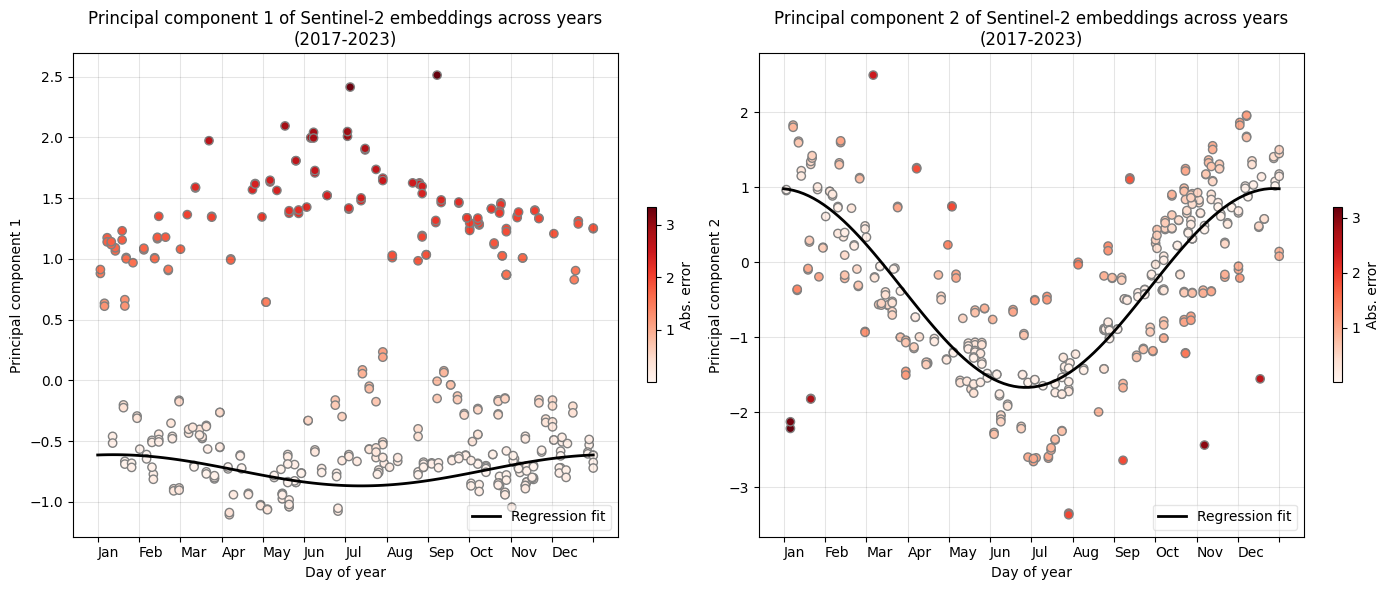

In [123]:
plt.close('all')
fig, axs = plt.subplots(1, 2, figsize=(14, 6), squeeze=True, tight_layout=True)
cmap = plt.get_cmap('Reds')

for pc, ax in enumerate(axs.flat):
    lr = RANSACRegressor()
    Y = pca_emb[:, pc]
    X = t_to_feats(t_foy)
    _ = lr.fit(X, Y)

    x = t_foy
    y_pred = lr.predict(t_to_feats(x))
    error = np.abs(y_pred - pca_emb[:, pc])
    norm = Normalize(error.min(), error.max())
    cols = cmap(norm(error))
    ax.scatter(x, pca_emb[:, pc], c=cols, ec='gray', alpha=1)

    t = np.linspace(0, 1, 100)
    x = t_to_feats(t)
    y_pred = lr.predict(x)
    ax.plot(t, y_pred, lw=2, c='k', label='Regression fit')
    ax.legend(loc='lower left')
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    # sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.015, label='Abs. error')
    
    ax.legend(loc='lower right', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_xticks(np.arange(0, 13) / 12, 
                  ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', ''])
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 embeddings across years\n(2017-2023)')
    ax.set_xlabel('Day of year')
    ax.set_ylabel(f'Principal component {pc + 1}')

plt.show()

In [118]:
def to_t_day(date):
    timetuple = datetime.strptime(date, '%Y-%m-%d').timetuple()
    year = timetuple.tm_year
    doy = np.clip(timetuple.tm_yday / 365, 0, 1)
    return year + doy

t_day = np.array([to_t_day(date) for date in dates])


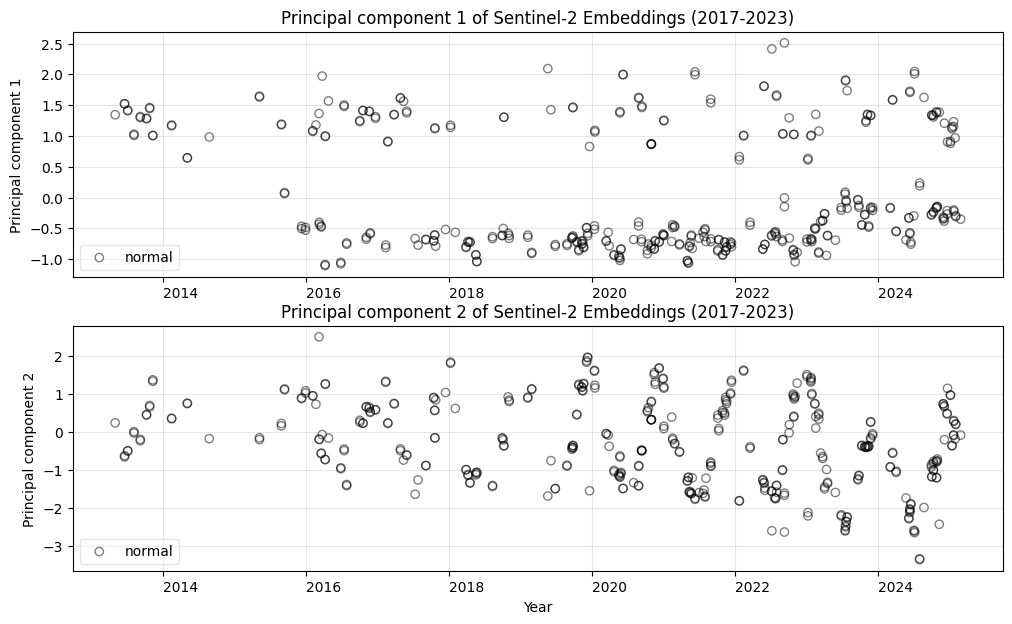

In [124]:
plt.close('all')
fig, axs = plt.subplots(2, 1, figsize=(12, 7), squeeze=True)

for pc, ax in enumerate(axs):
    ax.scatter(t_day, pca_emb[:, pc], ec='k', fc='none', alpha=0.5, label='normal')
    
    ax.legend(loc='lower left', framealpha=0.5)
    ax.grid('--', c='k', alpha=0.1)
    ax.set_title(f'Principal component {pc + 1} of Sentinel-2 Embeddings (2017-2023)')
    # ax.set_xlim((2016, 2025))
    for tick in ax.xaxis.get_majorticklabels():
        tick.set_horizontalalignment('left')
    ax.set_ylabel(f'Principal component {pc + 1}')
    if pc == len(axs) - 1:
        ax.set_xlabel('Year')

plt.show()